# 1. Аудит многоканального ряда синхронизации

**Цели:** проверить схему, пропуски и масштаб каждого канала перед любым анализом. Этот ряд (`kuramoto_propagation_series.csv`) — синтетический пример с известным впрыснутым событием и исходным каналом; их провенанс — в `synthetic_datasets_metadata.json`. Аудит здесь намеренно их не использует: это первый, "наивный" взгляд на данные, как если бы разметки не было.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_propagation_series.csv").exists())
DATA = ROOT / "data/generated/kuramoto_propagation_series.csv"
SEED = 42
rng = np.random.default_rng(SEED)
df = pd.read_csv(DATA)
channel_names = [column for column in df.columns if column.startswith("channel_")]
x = df[channel_names].to_numpy()
assert np.isfinite(x).all() and x.ndim == 2

summary = df[channel_names].describe(percentiles=[.01, .05, .5, .95, .99]).T
summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
channel_00,1500.0,-0.014806,0.756186,-3.009790,-0.999995,-0.991932,-0.017153,0.986339,0.999859,4.312083
channel_01,1500.0,0.014132,0.723296,-2.032004,-0.999970,-0.989907,0.034038,0.987924,0.999781,2.834632
channel_02,1500.0,-0.037360,0.706186,-1.387518,-0.999693,-0.989621,-0.065569,0.983145,0.999482,1.883383
channel_03,1500.0,-0.008370,0.709191,-0.999997,-0.999480,-0.987688,-0.025402,0.988882,0.999668,1.383791
channel_04,1500.0,-0.044680,0.707634,-1.000000,-0.999514,-0.989543,-0.082507,0.983369,0.999249,0.999997
channel_05,1500.0,-0.071956,0.696804,-1.000000,-0.999573,-0.989620,-0.143051,0.981595,0.999177,1.000000
channel_06,1500.0,-0.012504,0.703850,-0.999994,-0.999495,-0.987835,-0.022349,0.983610,0.999232,0.999999
channel_07,1500.0,-0.023411,0.700888,-1.000000,-0.999500,-0.988055,-0.039703,0.981514,0.999220,0.999999
channel_08,1500.0,-0.047711,0.706453,-0.999997,-0.999545,-0.989941,-0.087768,0.983150,0.999330,0.999999
channel_09,1500.0,0.013967,0.702106,-1.000000,-0.999439,-0.986167,0.025062,0.987361,0.999491,1.353099


{'rows': 1500,
 'columns': ['timestamp',
  'channel_00',
  'channel_01',
  'channel_02',
  'channel_03',
  'channel_04',
  'channel_05',
  'channel_06',
  'channel_07',
  'channel_08',
  'channel_09',
  'channel_10',
  'channel_11',
  'is_extreme'],
 'extra_label_column': 'is_extreme'}

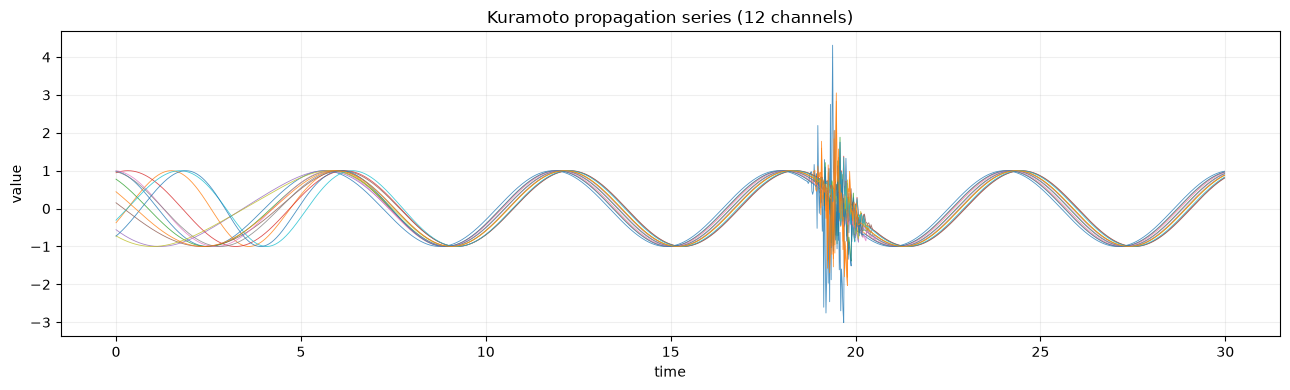

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["timestamp"], x, lw=.6, alpha=.8)
ax.set(title=f"Kuramoto propagation series ({len(channel_names)} channels)", xlabel="time", ylabel="value")
ax.grid(alpha=.2); fig.tight_layout()
{"rows": len(df), "columns": list(df.columns), "extra_label_column": "is_extreme"}

Колонка `is_extreme` уже видна в схеме, но её значение (0/1, окно события) мы здесь пока не интерпретируем — так же, как в аудите одномерного ряда (`1-d/01`) не используется `is_extreme` для выбора baseline. Ниже — единственное исключение: посмотрим, что происходит со скейлингом ряда (DFA) в точности там, где эта метка стоит.

## От гладкой синхронизации к шероховатости: DFA-экспонента и впрыснутое событие

Detrended Fluctuation Analysis (DFA) оценивает, как растёт размах отклонений от локального тренда с масштабом окна: наклон `log(fluctuation)` от `log(scale)` — экспонента `α`. Гладкий, предсказуемый сигнал (например, синусоида Курамото на устоявшемся участке) даёт `α`, близкую к 2; шероховатый, окрашенный шум даёт `α`, близкую к своему параметру Hurst. Посчитаем `α` в скользящем окне по исходному каналу (`source_channel` из `synthetic_datasets_metadata.json`) и наложим окно `is_extreme` — впервые в этом ноутбуке используя разметку, только чтобы *увидеть* связь, а не чтобы что-то по ней решать.

In [3]:
import json

event_mask = df["is_extreme"].to_numpy(dtype=bool)
propagation_metadata = json.loads((ROOT / "data/generated/synthetic_datasets_metadata.json").read_text())["kuramoto_propagation"]
source_channel = int(propagation_metadata["source_channel"])
injected_hurst = float(propagation_metadata["hurst_exponent"])
x_source = df[channel_names[source_channel]].to_numpy()


def dfa_alpha(segment: np.ndarray, scales: tuple[int, ...]) -> float:
    """Detrended Fluctuation Analysis exponent of one segment (same math as
    graph_evt_agent.graph.dfa_graph, applied to a single rolling window)."""
    profile = np.cumsum(segment - segment.mean())
    fluctuation = []
    for scale in scales:
        count = len(profile) // scale
        if count < 2:
            return np.nan
        segments = profile[: count * scale].reshape(count, scale)
        design = np.column_stack([np.arange(scale, dtype=float), np.ones(scale)])
        trend = (design @ np.linalg.lstsq(design, segments.T, rcond=None)[0]).T
        fluctuation.append(np.sqrt(np.mean((segments - trend) ** 2)))
    return np.polyfit(np.log(scales), np.log(np.maximum(fluctuation, 1e-12)), 1)[0]


DFA_SCALES = (8, 16, 32, 64)
WINDOW, STEP = 200, 10
starts = np.arange(0, len(x_source) - WINDOW, STEP)
rolling_alpha = np.array([dfa_alpha(x_source[start:start + WINDOW], DFA_SCALES) for start in starts])
window_centers = starts + WINDOW // 2

pd.DataFrame({"window_center": window_centers, "alpha": rolling_alpha}).describe()

,window_center,alpha
count,130.000000,130.000000
mean,745.000000,1.797910
std,376.718286,0.440387
min,100.000000,0.689158
25%,422.500000,1.992567
50%,745.000000,2.002489
75%,1067.500000,2.013568
max,1390.000000,2.021090


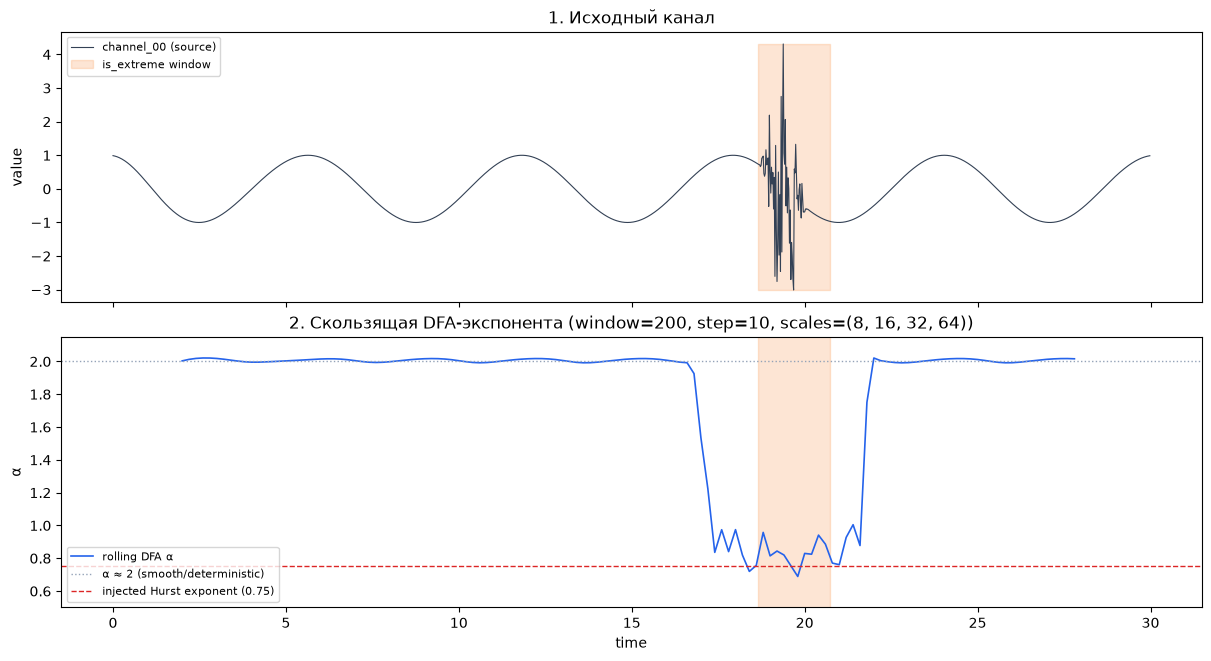

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, constrained_layout=True)

axes[0].plot(df["timestamp"], x_source, color="#334155", linewidth=0.8, label=f"{channel_names[source_channel]} (source)")
axes[0].fill_between(df["timestamp"], x_source.min(), x_source.max(), where=event_mask,
                      color="#f97316", alpha=0.18, label="is_extreme window")
axes[0].set(title="1. Исходный канал", ylabel="value")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(df["timestamp"].to_numpy()[window_centers], rolling_alpha, color="#2563eb", linewidth=1.2, label="rolling DFA α")
axes[1].fill_between(df["timestamp"], 0, 2.2, where=event_mask, color="#f97316", alpha=0.18)
axes[1].axhline(2.0, color="#94a3b8", linestyle=":", linewidth=1, label="α ≈ 2 (smooth/deterministic)")
axes[1].axhline(injected_hurst, color="#dc2626", linestyle="--", linewidth=1, label=f"injected Hurst exponent ({injected_hurst:g})")
axes[1].set(title=f"2. Скользящая DFA-экспонента (window={WINDOW}, step={STEP}, scales={DFA_SCALES})",
            xlabel="time", ylabel="α", ylim=(0.5, 2.15))
axes[1].legend(loc="lower left", fontsize=8)
plt.show()

Вне окна события `α` держится почти ровно на `2.0` — сигнал источника вне впрыска это гладкая, предсказуемая синусоида Курамото. Как только скользящее окно начинает захватывать `is_extreme`, `α` резко падает и колеблется около впрыснутого `hurst_exponent` (`0.75`) — именно потому, что событие *буквально* сгенерировано как Hurst-окрашенный шум (`generate_kuramoto_propagation_series`, см. `scripts/generate_datasets.py`). Это не предсказание нового факта, а проверка того, что генератор данных делает то, что заявлено — и побочно демонстрирует, что DFA-экспонента в принципе чувствительна к такому типу события, задолго до того, как EVT-детекция (ноутбук 3) вообще вступает в игру.

**Самопроверка:** почему `α ≈ 2` — ожидаемое значение для гладкой синусоиды, а не артефакт? Почему провал `α` шире самого `is_extreme`-окна (в обе стороны) — за счёт чего именно? Стал бы этот сигнал подходящей *ранней* тревогой, если событие короче окна `WINDOW=200`? Что теряется при усреднении по каналам в разделе выше и почему DFA здесь посчитана только для одного канала, а не сразу для всех?